# Contexto:
Un ingeniero civil necesita predecir la resistencia a la compresión del concreto antes de que fragüe para poder tomar decisiones de diseño estructural.

Se tienen datos históricos de 1,030 mezclas de concreto, cada una descrita por 8 variables:

* cantidad de cemento
* escoria de alto horno
* ceniza volante
* agua
* superplastificante
* agregado grueso
* agregado fino
* edad del concreto en días

La variable objetivo es la resistencia en MPa.

El propósito de esta actividad es construir una red neuronal para ese mismo problema, entender qué está pasando en cada paso, y al final hacer la pregunta correcta: ¿la complejidad adicional se justifica?

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

# ── Reproducibilidad ─────────────────────────────────────────
SEED = 9091989
torch.manual_seed(SEED)
np.random.seed(SEED)

# ── Dispositivo ──────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"PyTorch version : {torch.__version__}")
print(f"Dispositivo     : {device}")
print("Entorno listo.")

PyTorch version : 2.10.0+cpu
Dispositivo     : cpu
Entorno listo.


* *Pregunta 0.1 ¿Por qué fijamos SEED =... al principio y no al final, ni en ningún otro momento? ¿Qué procesos dentro del entrenamiento de una red neuronal son probabilistas y se verían afectados si no hubieras fijado la semilla?*


La semilla es fijada al principio de todo código para que todas las librerias que se usen durante todo el proceso usen el mismo generador inicial de números pseudoaleatorios. Al fijar la semilla en otra sección, las operaciones random que hayan ocurrido antes de esta línea habrán usado una semilla impredecible. Con esto se pierde la reproducibilidad, haciendo imposible que se obtengan las mismas métricas al correr de nuevo el código.

Dentro de las redes neuronales, la asignación de pesos y sesgos iniciales se inicializan de forma aleatoria. Al no fijar una semilla, la red neuronal empezará en un punto distinto del espacio de pérdida en cada ejecución. Otro proceso probabilista primordial dentro de las redes neuronales es la división de train/test; por lo que no se tendrán la misma información si el código se ejecuta más de una vez, por lo que los resultados no coincidirían y las métricas no tendrían el mismo resultado.


* *Pregunta 0.2 La celda imprime el dispositivo. La gran mayoría de ustedes verá cpu. ¿Por qué para este problema específico (1,030 muestras, 8 features, red pequeña) eso no es un problema? ¿En qué tipo de problema sí necesitarías GPU?*


El dataset presenta solamentye 1030 filas y 8 features, aunado la arqutectura pequeña de la red; la cantidad de multiplicaciones que requiere computacionalmente es pequeña. Actualmente, las CPUs son rápidasd procesando cargas de trabajo secuenciales o de paralelismo moderado.

En el caso de un paralelismo masivo, se ocuparía usar el GPU. Esto se considera al presentar datasets con datos de alta dimensionalidad tales como imágenes, videos, etc. ; modelos con arquitecturas complejas con miles de parámetros e incluso datasets masivos con millones dee registros. 

# Parte 1: Datos
## 1.1 Carga y exploración inicial

In [2]:
url = ("https://archive.ics.uci.edu/ml/machine-learning-databases"
       "/concrete/compressive/Concrete_Data.xls")

df = pd.read_excel(url)
df.columns = [
    "cemento", "escoria", "ceniza", "agua",
    "superplast", "agregado_grueso", "agregado_fino",
    "edad", "resistencia"
]

print(f"Dimensiones: {df.shape}")
print(f"\nValores nulos:\n{df.isnull().sum()}")
print(f"\nEstadísticas descriptivas:")
df.describe().round(2)

Dimensiones: (1030, 9)

Valores nulos:
cemento            0
escoria            0
ceniza             0
agua               0
superplast         0
agregado_grueso    0
agregado_fino      0
edad               0
resistencia        0
dtype: int64

Estadísticas descriptivas:


,cemento,escoria,ceniza,agua,superplast,agregado_grueso,agregado_fino,edad,resistencia
count,1030.00,1030.00,1030.00,1030.00,1030.00,1030.00,1030.00,1030.00,1030.00
mean,281.17,73.90,54.19,181.57,6.20,972.92,773.58,45.66,35.82
std,104.51,86.28,64.00,21.36,5.97,77.75,80.18,63.17,16.71
min,102.00,0.00,0.00,121.75,0.00,801.00,594.00,1.00,2.33
25%,192.38,0.00,0.00,164.90,0.00,932.00,730.95,7.00,23.71
50%,272.90,22.00,0.00,185.00,6.35,968.00,779.51,28.00,34.44
75%,350.00,142.95,118.27,192.00,10.16,1029.40,824.00,56.00,46.14
max,540.00,359.40,200.10,247.00,32.20,1145.00,992.60,365.00,82.60


* *Pregunta El dataset tiene 1,030 observaciones. GPT-3 fue entrenado con aproximadamente 300 mil millones de tokens. ¿Qué implica esa diferencia de escala para la elección entre una red neuronal profunda y un modelo lineal? Antes de ver los resultados de esta actividad...qué esperas encontrar?*

Una red neuronal profunda requiere una gran cantidad de datos para poder entrenarse, por lo que al presentar pocos datos para este tipo de redes se espera que sufra un overfitting. Utilizar una herramienta con una capacidad tan grande y tan pocos datos para poder aprender, la red neuronal no extraerá patrones generales de los datos; si no que memorizará el ruido de los datos y las particularidades de las 1030 muestras. Pequeños cambios en los datos (cantidad de agua, cemento, la edad, etc.) de entrenamiento pueden presentar grandes cambios en el modelo (varianza alta).

En comparación, un modelo liineal simple es probable que obtenga métricas de evaluación más reales que la de la red neuronal profunda. Al ser un modelo más rígido se obtiene menor varianza dentro de los datos; y por ende evita la memorización excesiva de un dataset pequeño.

## 1.2 Exploración visual

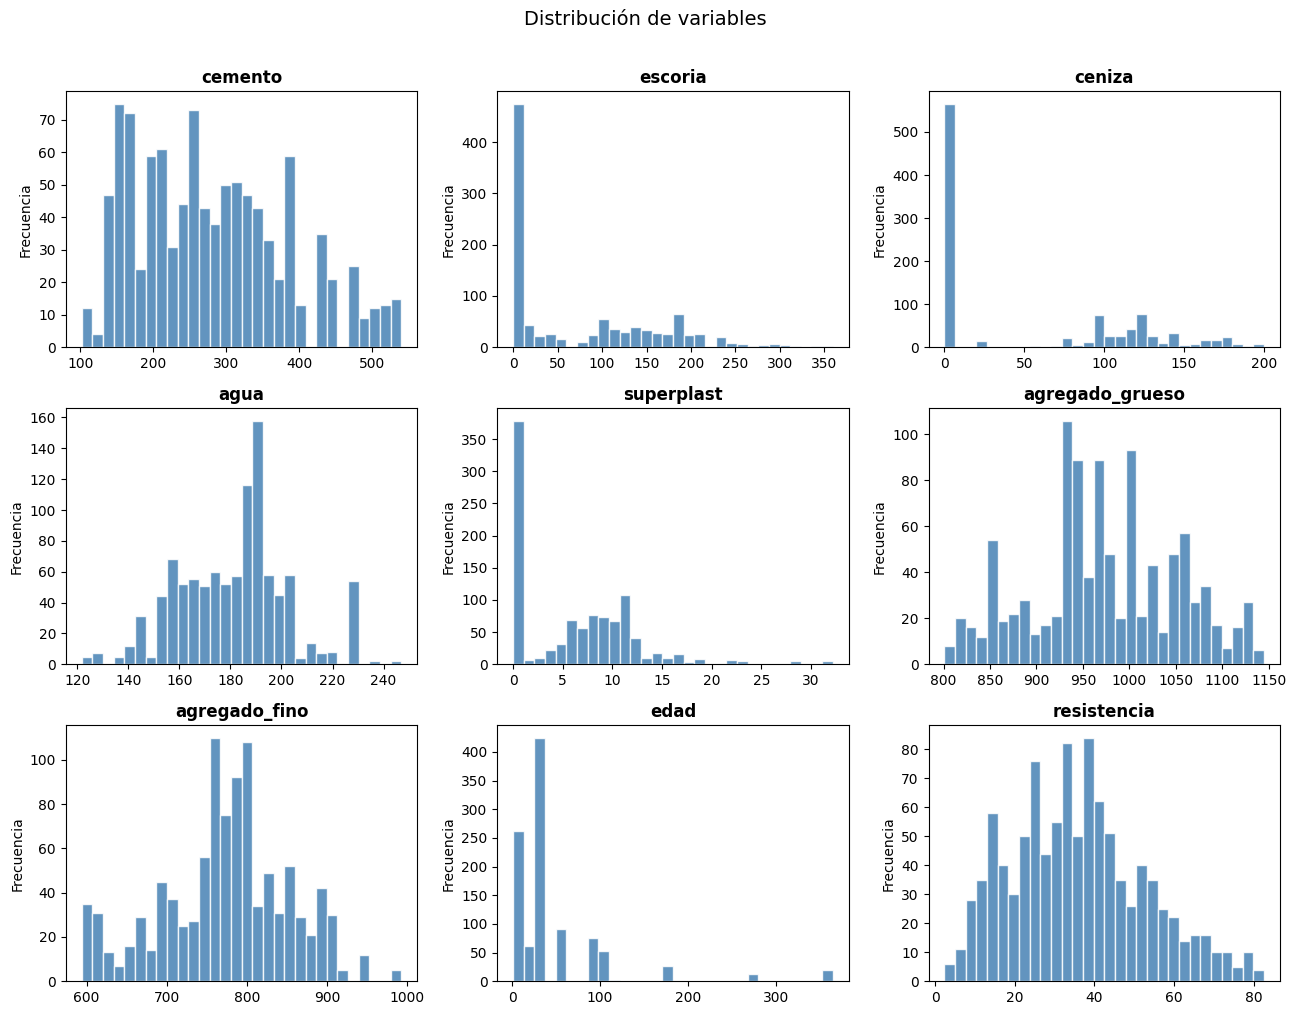

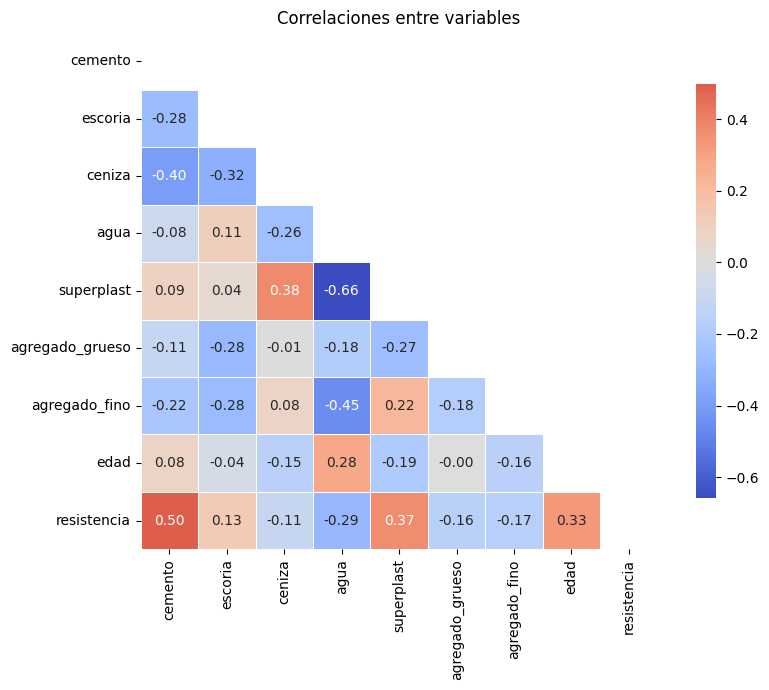

In [3]:
fig, axes = plt.subplots(3, 3, figsize=(13, 10))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    axes[i].hist(df[col], bins=30, color="steelblue", edgecolor="white", alpha=0.85)
    axes[i].set_title(col, fontweight="bold")
    axes[i].set_ylabel("Frecuencia")

plt.suptitle("Distribución de variables", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Mapa de correlación
plt.figure(figsize=(9, 7))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", center=0, square=True,
            linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Correlaciones entre variables")
plt.tight_layout()
plt.show()

* *Pregunta 1.2 Observa el histograma de edad. Describe su distribución. ¿Es aproximadamente normal? ¿Por qué importa la distribución de las variables de entrada antes de pasarlas a una red neuronal?*

La distribución de edad presenta un sesgo a la derecha, por lo que no es una distribución normal. Se observan que hay valores que concentran la mayoría de los datos con picos muy marcados (menores de 50 días), lo que podría corresponder a un estándar en las pruebas de concreto; y una cola larga que se extiene a la derecha con valores atípicos que llegan a más de 300 días. 

Es primordial conocer la distribución de las variables antes de realizar una red neuronal, debido a que estas aprenden usando el gradiente. Al presentar variables con distribuciones con alto sesgo, se alarga y se vuelve asimétrico el espacio de pérdida. De igual forma, las funciones de activación necesitan que las entradas estén centradas para poder operar en un rango óptimo y evitar el vanishing gradient. En el caso que se tengan distribuciones sesgadas suele requerirse transformaciones y estandarizaciones antes de entrar a la red. 

* *Pregunta 1.3 Mira el mapa de correlaciones. ¿Cuál variable tiene mayor correlación con resistencia? ¿Eso significa que una red neuronal sólo necesitaría esa variable para predecir bien?*

La variable de cantidad de cemento presenta una correlación fuerte positiva de 0.50, siguiendo con superplast con 0.37 y la edad con 0.33.

Al escoger sólo la variable de cemento para la red neuronal es un error debido a que la correlación indica una relación lineal positiva entre la resistencia, pero no la suficiente para poder explicar la variabilidad de los valores que toma. Existe más información contenida en las demás variables que puede ayudar a describir este fenómeno. Aunado a esto, las redes neuronales tienen la capacidad de aproximar funciones complejas y capturar relaciones no lineales; por lo que otras variables con baja correlación lineal pueden volverse buenos predictores cuando la red las combina internamente. 

## 1.3 División y escalado

In [4]:
X = df.drop("resistencia", axis=1).values   # shape: (1030, 8)
y = df["resistencia"].values.reshape(-1, 1) # shape: (1030, 1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.15, random_state=SEED
)

print(f"Train : {X_train.shape[0]} muestras")
print(f"Val   : {X_val.shape[0]} muestras")
print(f"Test  : {X_test.shape[0]} muestras")

# Escalado
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_sc = scaler_X.fit_transform(X_train)
X_val_sc   = scaler_X.transform(X_val)
X_test_sc  = scaler_X.transform(X_test)

y_train_sc = scaler_y.fit_transform(y_train)
y_val_sc   = scaler_y.transform(y_val)
y_test_sc  = scaler_y.transform(y_test)

Train : 700 muestras
Val   : 124 muestras
Test  : 206 muestras


* *Pregunta 1.4 Esta vez hay tres conjuntos: train, val y test. ¿Cuál es la función específica del conjunto de validación que no puede cumplir el conjunto de prueba? Si usaras el test set para early stopping, ¿qué error conceptual estarías cometiendo?*

El conjunto de validación es utilizado para poder evaluar el proceso de entrenamiento del modelo. Este conjunto ayuda a afinar y optimizar los hiperparámetros. El conjunto de prueba (test), por el contrario, debe permanecer completamente bloqueado y oculto hasta el final del proyecto. Su única función es darte una estimación honesta y sin sesgos de cómo se comportará tu modelo final en el mundo real.

El tema con usar el early stopping con el test set es que nunca se debe de optimizar un modelo usando los datos de prueba. Si usas el test set para decidir en qué momento detener el entrenamiento, el modelo está tomando decisiones de aprendizaje basadas en esos datos. El test set perdería su finalidad y se convertiría, en la práctica, en un segundo conjunto de validación. Como resultado, la métrica final de evaluación sería excesivamente optimista y no reflejaría el rendimiento real del modelo ante datos verdaderamente nuevos.

* *Pregunta 1.5 X_val_sc y X_test_sc usan .transform(), no .fit_transform(). Explica por qué esto es importante en términos de lo que el modelo "puede saber" sobre los datos. ¿Qué nombre tiene este tipo de error cuando se comete?*

Al usar el .fit_transform() se aprende parámetros estadísticos sobre los datos en los cuales se aplican (los de train) y después transforma los datos 
utilizando estos cálculos. El .transform() solo aplica la transformación con los cálculos memorizados en el proceso de .fit_transform(). Esto se realiza debido a que en datos futuros y desconocidos, no se conoce la media ni otro estadístico, sólo sobre los datos históricos. 

Cometer un error de este tipo se le conoce como Data Leakage, debido a que se permite que información del conjunto de validación o de prueba influyan al entrenamiento del modelo. Esto hace creer que el modelo es excelente, pero el rendimiento en datos nuevos y reales falla.  

* *Pregunta 1.6 Estamos escalando también y. Escalar el target no siempre es necesario en regresión lineal, pero en redes neuronales es común. Menciona dos razones técnicas por las que escalar el target puede ayudar al entrenamiento de una red.*

En redes neuronales el aprendizaje se da calculando el error y con el backpropagation (propagar el erro hacia atrás para actualizar pesos). Si la variable target está en una escala muy grande la función de pérdida generará  valores enormes; y por ende los gradientes generados causarán cambios bruscos en el modelo que lo harán ineficiente. 

Por otra parte, al empezar a entrenar, los pesos y sesgos que se inicializan de manera aleatoria tendrían valores pequeños. Si la variable target no está escalada, le costaría al modelo decenas de 'épocas' para poder alcanzar los valores esperados, perdiendo el aprendizaje de los patrones y sutilezas de los datos. Escalar el target pone a las predicciones iniciales y a los valores reales en la misma línea de salida.

## 1.4 Conversión a tensores

In [5]:
def to_tensor(array):
    return torch.tensor(array, dtype=torch.float32).to(device)

X_train_t = to_tensor(X_train_sc)
X_val_t   = to_tensor(X_val_sc)
X_test_t  = to_tensor(X_test_sc)
y_train_t = to_tensor(y_train_sc)
y_val_t   = to_tensor(y_val_sc)
y_test_t  = to_tensor(y_test_sc)

train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader  = DataLoader(train_dataset, batch_size=32, shuffle=True)

print(f"Tensor train X : {X_train_t.shape}  dtype={X_train_t.dtype}")
print(f"Tensor train y : {y_train_t.shape}  dtype={y_train_t.dtype}")


Tensor train X : torch.Size([700, 8])  dtype=torch.float32
Tensor train y : torch.Size([700, 1])  dtype=torch.float32


* *Pregunta 1.7 ¿Por qué usamos float32 y no float64 (doble precisión)? ¿Cuándo el uso de float64 podría ser importante?*

Un número float32 ocupa la mitad del espacio que un float64; por lo que usar los primeros nos da la ventaja de que los conjunto de datos, pesos y gradientes ocupen la mitad del espacio en la RAM. Esto ayuda a acelerar las transferencias de memoria y cálculos. Junto con esto, las redes neuronales son tolerantes al ruido numérico, por lo que la precisión decimal de un float64 no es tan necesaria para el proceso que implica. 

En casos donde los errores acumulados puden destruir cálculos o en general que se necesite una mayor precisión de datos es mejor usar datos en float64. Esto puede ocurrir en simulaciones de sistemas físicos sofisticados por ejemplo.

* *Pregunta 1.8 DataLoader recibe shuffle=True. En clase viste qué es un epoch (slide 104 del lunes). ¿Por qué tiene sentido mezclar los datos en cada epoch? ¿Qué problema concreto estás evitando?*

Cuando usamos el shuffle = True, indicamos que se mezclen aleatoriamente todas las filas del dataset antes de partirtlas en los mini-batches al inicio de cada época (epoch). Al mezclar los datos nos aseguramos que el contenido de cada lote sea una muestar representativa de la distribución general de los datos en cada iteración que se realice. 

Con esto, ayudamos a generalizar el aprendizaje de la red neuronal, evitando la memorización del orden y ciclos repetitivos dentro del proceso. 


# Parte 2: El forward pass (primero a mano, luego en código)

Esta parte no tiene paralelo en la mayoría de tutoriales de PyTorch.

La incluimos porque si entiendes qué hace PyTorch línea por línea, nunca será una caja negra para ti.

## 2.1 Un forward pass manual con números pequeños
Antes de definir tu red real, vas a calcular un forward pass a mano en una red de juguete. Lee con cuidado.

Considera una red con:

* 2 entradas: x1 = 0.5, x2 = -1.0
* 1 capa oculta con 2 neuronas y activación ReLU
* 1 neurona de salida (sin activación)
Los pesos y biases ya están fijos (en la práctica los inicializa PyTorch, aquí los damos nosotros):

**Parámetros de la Red:**
* **Capa 1:** $$W_1 = \begin{bmatrix} 0.3 & 0.8 \\ -0.5 & 0.2 \end{bmatrix}, \quad b_1 = \begin{bmatrix} 0.1 \\ -0.3 \end{bmatrix}$$
* **Capa 2:** $$W_2 = \begin{bmatrix} 0.6 & -0.4 \end{bmatrix}, \quad b_2 = [0.0]$$

---

#### 1. Pre-activación de la capa 1 ($z_1$)
Calculamos $z_1 = W_1 \cdot x + b_1$ con $x = \begin{bmatrix} 0.5 \\ -1.0 \end{bmatrix}$:

$$z_1 = \begin{bmatrix} 0.3 & 0.8 \\ -0.5 & 0.2 \end{bmatrix} \begin{bmatrix} 0.5 \\ -1.0 \end{bmatrix} + \begin{bmatrix} 0.1 \\ -0.3 \end{bmatrix}$$

$$z_1 = \begin{bmatrix} (0.3 \cdot 0.5) + (0.8 \cdot -1.0) \\ (-0.5 \cdot 0.5) + (0.2 \cdot -1.0) \end{bmatrix} + \begin{bmatrix} 0.1 \\ -0.3 \end{bmatrix}$$

$$z_1 = \begin{bmatrix} 0.15 - 0.8 \\ -0.25 - 0.2 \end{bmatrix} + \begin{bmatrix} 0.1 \\ -0.3 \end{bmatrix} = \begin{bmatrix} -0.65 \\ -0.45 \end{bmatrix} + \begin{bmatrix} 0.1 \\ -0.3 \end{bmatrix} = \begin{bmatrix} -0.55 \\ -0.75 \end{bmatrix}$$

#### 2. Activación ($a_1$)
Aplicamos la función $\text{ReLU}(z) = \max(0, z)$ elemento a elemento:

$$a_1 = \text{ReLU}\left( \begin{bmatrix} -0.55 \\ -0.75 \end{bmatrix} \right) = \begin{bmatrix} 0.0 \\ 0.0 \end{bmatrix}$$

#### 3. Pre-activación de la capa 2 ($z_2$)
Calculamos $z_2 = W_2 \cdot a_1 + b_2$:

$$z_2 = \begin{bmatrix} 0.6 & -0.4 \end{bmatrix} \begin{bmatrix} 0.0 \\ 0.0 \end{bmatrix} + [0.0]$$

$$z_2 = (0.6 \cdot 0.0) + (-0.4 \cdot 0.0) + 0.0 = 0.0$$

#### 4. Salida ($\hat{y}$)
$$\hat{y} = z_2 = 0.0$$

#### 5. Cálculo del Error (MSE)
Si el valor real es $y = 2.0$:

$$\text{MSE} = (\hat{y} - y)^2 = (0.0 - 2.0)^2 = 4.0$$


Ahora verifica tu cálculo con código:


In [6]:
# Red de verificación (NO es tu modelo final, es solo para verificar el cálculo manual)
x_toy  = torch.tensor([[0.5, -1.0]])
W1 = torch.tensor([[0.3, 0.8], [-0.5, 0.2]])  # PyTorch: filas = neuronas de salida
b1 = torch.tensor([[0.1, -0.3]])
W2 = torch.tensor([[0.6, -0.4]])
b2 = torch.tensor([[0.0]])

z1 = x_toy @ W1.T + b1
a1 = torch.relu(z1)
z2 = a1 @ W2.T + b2

print(f"z1 = {z1}")
print(f"a1 = {a1}")
print(f"z2 (ŷ) = {z2}")
y_toy = torch.tensor([[2.0]])
mse   = ((z2 - y_toy) ** 2).mean()
print(f"MSE = {mse.item():.6f}")

z1 = tensor([[-0.5500, -0.7500]])
a1 = tensor([[0., 0.]])
z2 (ŷ) = tensor([[0.]])
MSE = 4.000000


* *Pregunta 2.1 ¿Coincide con la salida del código? Si hay discrepancia, ¿dónde está el error?*

    Coincide el error calculado a mano con el código proporcionado. 

* *Pregunta 2.2 En el paso de ReLU, si Z1[1] hubiera sido negativo, ¿qué valor tomaría A1[1]? ¿Qué implicación tiene eso para el gradiente de esa neurona durante backpropagation? ¿Cómo se llama ese fenómeno?*

    Si en Z1 se presentan valores negativos, la función ReLU lo transforma a 0. Al aplicar la regla de la cadena durante la backpropagation, el gradiente de error que intente fluir hacia atrás a través de esta neurona se multiplicará por cero. Esto detiene el flujo de información, provocando que los pesos y el sesgo que alimentan a esa neurona específica no se actualicen en absoluto durante ese paso de entrenamiento.

  A este fenómeno se le denomina como Neurona Muerta, debido a que la neurona dejará de aprender y se volverá un nodo inútil en la red.


## 2.2 Definición del modelo 
Ahora sí, la red que vas a entrenar con el dataset de concreto:

In [7]:
class ConcreteNet(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, dropout_rate=0.0):
        super(ConcreteNet, self).__init__()
        
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(p=dropout_rate),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(p=dropout_rate),
            nn.Linear(hidden_dim, output_dim)
        )
    
    def forward(self, x):
        return self.network(x)

model = ConcreteNet(input_dim=8, hidden_dim=64, output_dim=1, dropout_rate=0.0).to(device)
print(model)
print(f"\nTotal de parámetros: {sum(p.numel() for p in model.parameters()):,}")

ConcreteNet(
  (network): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.0, inplace=False)
    (3): Linear(in_features=64, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.0, inplace=False)
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
)

Total de parámetros: 4,801


* *Pregunta 2.3 El código imprime el total de parámetros automáticamente. Antes de ejecutar la celda, calcula ese número a mano para la arquitectura 8 -> 64 -> 64 -> 1. Muestra el desglose por capa (pesos + sesgos). ¿Coincide?*

  Capa 1: 8 * 64 + 64  = 576

  Capa 2: 64 * 64 + 64 = 4160

  Capa 3: 64 * 1 + 1 = 65

  Total = 4801 parámetros

  Sí coincide.
  
* *Pregunta 2.4 La capa de salida no tiene función de activación. ¿Por qué? ¿Qué pasaría si agregáramos ReLU al final en este problema? ¿Podría eso causar un error sistemático en las predicciones?*

  Se trata de una regresión, debido a que queremos predecir la resistencia del concreto, que es un valor contionuo. Es requerido una salida que tome cualquier valor real. Al usar la función ReLU estamos restringiendo el rango de salida y nunca podrá tomar valores negativos. El problema surge debido a que anteriormente escalamos las variables, por lo que la media de la resistencia del concreto es de 0; con esto puede ocurrir que la mitad de los valores sean perdidos. 

  
* *Pregunta 2.5 nn.Sequential es una alternativa a escribir forward() manualmente. ¿Cuándo sería necesario escribir forward() explícitamente en lugar de usar nn.Sequential? Piensa en arquitecturas más complejas.*

  nn.Secuencial se utiliza en conexiones estrictamente lineales y presenta un flujo de datos único. Usar forward() ocurre cuando la arquitectura del fenómeno rompe con la linealidad, como cuando tenemos múltlipes entradas o salidas, algo como ramas o incluos en la lógica condicional. 

## 2.3 Inspección de pesos iniciales

Shape de W₁: torch.Size([64, 8])
Media de W₁: 0.0037
Std  de W₁: 0.2018
Min  de W₁: -0.3519
Max  de W₁: 0.3502


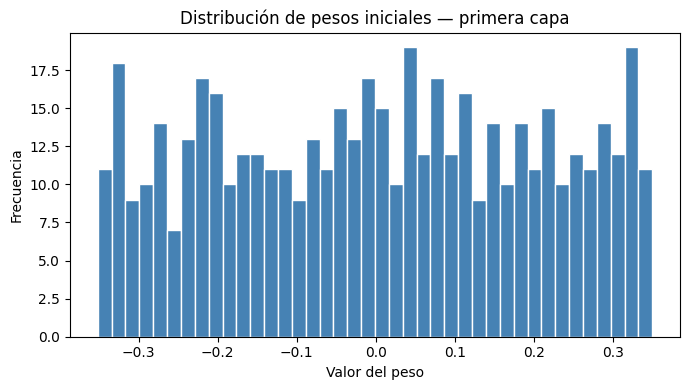

In [8]:
# Observar cómo PyTorch inicializa los pesos
primera_capa = list(model.parameters())[0]  # W de la primera capa: shape (64, 8)
print(f"Shape de W₁: {primera_capa.shape}")
print(f"Media de W₁: {primera_capa.data.mean():.4f}")
print(f"Std  de W₁: {primera_capa.data.std():.4f}")
print(f"Min  de W₁: {primera_capa.data.min():.4f}")
print(f"Max  de W₁: {primera_capa.data.max():.4f}")

plt.figure(figsize=(7, 4))
plt.hist(primera_capa.data.cpu().numpy().flatten(), bins=40,
         color="steelblue", edgecolor="white")
plt.title("Distribución de pesos iniciales — primera capa")
plt.xlabel("Valor del peso")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()


* *Pregunta 2.6 ¿Qué distribución tienen los pesos iniciales? PyTorch usa por default la inicialización de Kaiming He para capas con ReLU. ¿Por qué no inicializar todos los pesos en cero? ¿Qué problema fundamental causaría eso durante el entrenamiento? (Pista: piensa en lo que haría backpropagation si todos los pesos fueran idénticos.)*

    Se aprecia una distribución uniforme, donde hay valores entre aproximadamente -0.35 y 0.35. La inicialización Kaiming He acota los valores en el rango $$ U(-k, k)$$

  El caso de inicializar todos los pesos en cero generan una incapacidad de romper la simetría. Los forward pass serían idéntidos, por lo que todas las neuronas recibirían la misma entrada y generarían la misma salida de activación. De la mano, el gradiente sería idéntico para todas las neuronas de esa capa.
  Si ocurre esto, la capa colapsaría y se comportaría como su fuera una sola neurona.


# Parte 3: El ciclo de entrenamiento
Esta es la parte central de la actividad. Vas a construir el training loop explícito de PyTorch, que es exactamente el ciclo forward -> loss -> backward -> actualizar que viste en los slides del lunes.

## 3.1 Función de pérdida y optimizador

In [9]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

* *Pregunta 3.1 Se usa MSELoss. ¿Por qué MSE y no cross-entropy? ¿En qué tipo de tarea usarías cross-entropy binary y en cuál usarías cross-entropy multiclase?*

  Se utiliza debido a que el problema planteado se tarta de una regresión, el objetivo es predecir un valor numérico continuo (la resistencia del concreto) y el MSE penaliza las diferencias absolutas entre tu predicción y el valor real, castigando especialmente los errores grandes debido a que la diferencia se eleva al cuadrado.


  Cuando se presente un problema de clasificación, el Cross-Entropy es una opción relevante, debido a que se busca predecir la probabilidad de una observación pertenezca a una categoría en específico. El cross-entropy binary es eficaz cuando existen dos categorías en las cuales podemos trabaajar, como en el reto con la variable de retention. En la presencia de más clases, cross-entropy multiclase es una opción válida, debido al incremento de clases mutuamente excluyentes, como puede surgir en identificación de los tipos de anemias.
  
* *Pregunta 3.2 El optimizador es Adam con lr=1e-3. En clase viste que Adam mantiene estimaciones del primer y segundo momento del gradiente. Explica con tus palabras qué significa que los parámetros que "varían mucho" reciban pasos más pequeños. ¿Por qué eso puede ser ventajoso frente a un learning rate fijo para todos?*

    Cuando el gradiente de un peso en especfico es constantemente grande, la fórmula de Adam frena a estos valores, por lo que el paso efectivo se vuelve pequeño. Entonces si un parámetro varía mucho es debido a que sus gradientes tienen una magnitud alta de manera constante, o que presentan alta varianza.


  Al usar una learning rate fija puede ocurrir que si se escoge un paso grande en zonas planas, el cambio será violento; mientras que si escogemos un paso pequeño, podemos evitar oscilaciones en las pendientes, pero sería tardado avanzar en zonas planas. Adam escoge los pasos automáticamente. Frena los parámetros en las dimensiones empinadas (evitando que exploten) y acelera los parámetros en las dimensiones planas (permitiendo un aprendizaje rápido).

## 3.2 El training loop con early stopping
Lee todo el código antes de ejecutar. Cada línea tiene una razón de existir.

In [10]:
def train_model(model, train_loader, X_val_t, y_val_t,
                n_epochs=300, patience=20, verbose_every=25):
    """
    Entrena el modelo con early stopping basado en val loss.
    
    Args:
        patience : cuántos epochs tolerar sin mejora en val loss
                   antes de detener el entrenamiento.
    Returns:
        Historial de train loss y val loss por epoch.
    """
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    
    train_history = []
    val_history   = []
    
    # Variables para early stopping
    best_val_loss   = float("inf")
    best_weights    = None
    epochs_no_improv = 0
    stopped_at      = n_epochs
    
    for epoch in range(n_epochs):
        
        # ── MODO ENTRENAMIENTO ──────────────────────────────────────
        model.train()
        batch_losses = []
        
        for X_batch, y_batch in train_loader:
            
            # Paso 1: limpiar gradientes acumulados
            optimizer.zero_grad()
            
            # Paso 2: forward pass
            y_pred = model(X_batch)
            
            # Paso 3: calcular pérdida
            loss = criterion(y_pred, y_batch)
            
            # Paso 4: backward pass (calcular gradientes)
            loss.backward()
            
            # Paso 5: actualizar pesos
            optimizer.step()
            
            batch_losses.append(loss.item())
        
        train_loss = np.mean(batch_losses)
        train_history.append(train_loss)
        
        # ── MODO EVALUACIÓN ─────────────────────────────────────────
        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_val_t), y_val_t).item()
        val_history.append(val_loss)
        
        # ── EARLY STOPPING ──────────────────────────────────────────
        if val_loss < best_val_loss - 1e-4:
            best_val_loss    = val_loss
            best_weights     = {k: v.clone() for k, v in model.state_dict().items()}
            epochs_no_improv = 0
        else:
            epochs_no_improv += 1
        
        if epochs_no_improv >= patience:
            stopped_at = epoch + 1
            print(f"  Early stopping en epoch {stopped_at}.")
            break
        
        if (epoch + 1) % verbose_every == 0:
            print(f"  Epoch {epoch+1:3d} | Train: {train_loss:.4f} | Val: {val_loss:.4f}")
    
    # Restaurar los mejores pesos encontrados
    if best_weights is not None:
        model.load_state_dict(best_weights)
    
    return train_history, val_history, stopped_at


# Entrenamiento
print("Entrenando modelo base...")
train_hist, val_hist, stopped = train_model(model, train_loader, X_val_t, y_val_t)
print(f"Entrenamiento completado. Detenido en epoch {stopped}.")

Entrenando modelo base...
  Epoch  25 | Train: 0.0916 | Val: 0.1374
  Epoch  50 | Train: 0.0543 | Val: 0.1169
  Epoch  75 | Train: 0.0419 | Val: 0.1100
  Epoch 100 | Train: 0.0344 | Val: 0.1070
  Early stopping en epoch 114.
Entrenamiento completado. Detenido en epoch 114.


* *Pregunta 3.3 — La más importante de esta sección. Explica con tus propias palabras qué hace cada uno de los 5 pasos dentro del loop de batches. No copies las definiciones de los slides: formula la explicación en términos de lo que está ocurriendo matemáticamente con los pesos de esta red específica, con este dataset concreto.*
    Pasos:
  1. Limpiar gradientes: En PyTorch los gradientes se acumulan por parte de diseño. Esto representaría que los parametros no se actualicen de manera correcta, debido a que estaríamos trabajando con sesgos del batch pasado. Al poner en 0 nuestros gradientes, podemos conocer dentro de la vecindad hacia donde se produce el mayor aumento escalar
  2. Foward Pass: Se toman filas del dataset (agua, edad, cemento, etc.) , se multiplican por la matriz de pesos (W) y se le suman los sesgois (b) entre las capas ocultas de 64 neuronas. El resultado final es un vector con predicciones continuas, la resistencia del concreto calculada por la red.
  3. Calculo del error: Comparamos las resistencias del paso anterior y las reales. Se usa el MSE para penalizar a las predicciones que se alejaron mucho de los valores reales.
  4. Backpropagation: Se calculan las derivadas parciales del error con respecto a cada uno de los 4801 parámetros de la red. Ayuda a identificar aumentos pequeños y conectar variables con neuronas en específico.
  5. Actualización de paso: Usamos el optimizador Adam para definir el siguiente paso del siguiente batch. Usa el resultado del gradiante para ajustar la dirección contraria a este, ayudando a que la predicción vaya a 'converger'.
     
* *Pregunta 3.4 optimizer.zero_grad() está dentro del loop de batches, no fuera. ¿Qué pasaría si lo movieras fuera del loop (es decir, que se ejecutara solo una vez al inicio de cada epoch)? ¿Los pesos se actualizarían correctamente?*

  Sacarlo del loop de batches generaría una asignación erronea en los pesos. Como lo mencionaba antes, al no limpiar el gradiente en cada iteración se acumularían en cada batch procesado. Esto tiene fuertes implicaciones en la asignación de pesos, debido a que se aplicarian actualizaciones masivas y distorcionadas a la realidad, combinando la dirección del batch actual con la de los pasados. 
  
* *Pregunta 3.5 El bloque de evaluación usa model.eval() y torch.no_grad(). Son dos cosas distintas:*

  
  - model.eval() cambia el comportamiento de ciertas capas. ¿Cuáles capas de tu modelo se comportan diferente en modo evaluación vs entrenamiento, y por qué?
 
  La capa nn.Dropout, debido a que tiene una tasa de p = dropou_rate. Cuando se crea el modelo inicia en 0.0,  por lo que se apaga un porcentaje de neuronas en el proceso de entrenamiento. Durante la fase de evaluación, la red usa toda su capacidad para realizar una predicción. Entonces, al usar model.eval() 'apagamos' el Dropout para dejar todas las neuronas encendidas. 
        
  - torch.no_grad() evita que PyTorch construya el grafo computacional. ¿Qué es ese grafo y para qué lo usa backpropagation? ¿Por qué no lo necesitas durante la evaluación?

    Es como si fuera un mapa que PyTorch dibuja en la memoria RAM al hacer cálculos matemáticos. Al llamar loss.backward() se lee este mapa al revés para poder aplicar las derivadas y saber el ajuste exacto de los 4801 pesos de la red. Esto se aprende dentro del proceso de entrenamiento, por lo que no se debe de usar durante la evaluación; ya que no se plantea el aprendizaje en esta etapa, sino que se debe de predecir la resistencia del concreto.
 
    
* *Pregunta 3.6 El early stopping implementado guarda best_weights y los restaura al final con model.load_state_dict(best_weights). ¿Por qué es necesario ese paso de restauración? ¿Qué le estarías devolviendo al usuario si no lo hicieras?*

  Como definimos en patience = 20, el entrenamiento se detiene al reconocer que después de 20 epoch no hay mejora en la pérdida de validación, lo que implica que el modelo iniciaría un overfitting. Al no guardar best_weights estariamos mostrando los pesos del último epoch, lo que no siempre implica el punto más óptimo de la generalización.




## 3.3 Curvas de aprendizaje

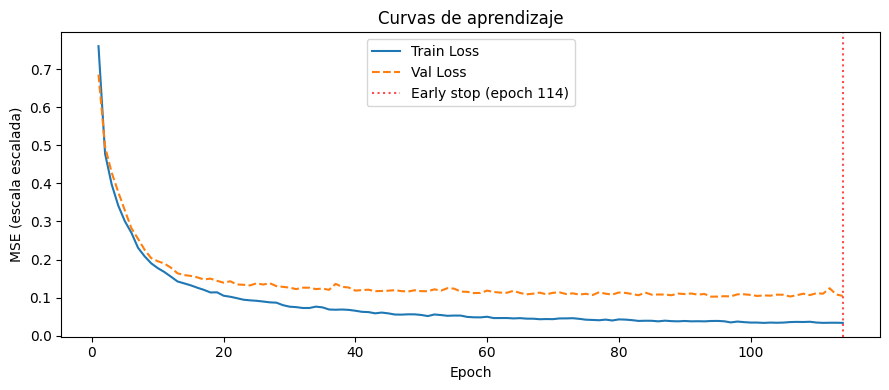

In [11]:
def plot_learning_curves(train_hist, val_hist, stopped_at, title="Curvas de aprendizaje"):
    plt.figure(figsize=(9, 4))
    epochs = range(1, len(train_hist) + 1)
    plt.plot(epochs, train_hist, label="Train Loss", linewidth=1.5)
    plt.plot(epochs, val_hist,   label="Val Loss",   linewidth=1.5, linestyle="--")
    plt.axvline(x=stopped_at, color="red", linestyle=":", alpha=0.7,
                label=f"Early stop (epoch {stopped_at})")
    plt.xlabel("Epoch")
    plt.ylabel("MSE (escala escalada)")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_learning_curves(train_hist, val_hist, stopped)

* *Pregunta 3.7 Pega tu gráfica aquí y describe lo que ves. Responde específicamente: a) ¿El val loss converge suavemente o tiene ruido? ¿A qué atribuyes eso? b) ¿Hay señal de overfitting? ¿Cómo lo identificas visualmente — no con un número, sino con la forma de las curvas? c) ¿La línea de early stopping está "en el lugar correcto", o debería haber esperado más o parado antes?*

  El Val Loss al inicio parece tener una caida suave y pronunciada, pero al estabilizarse en aproximadamente en el epoch 30 se nota la presencia de pequeños ruidos (no es una linea perfectamente lisa). Considero que estos problemas surgen debido al tamaño limitado del dataset; ya que con pocos datos las métricas se vuelven más sensibles.

  Existe una señal visual de overfitting, debido a que existe divergencia entre las brechas de las dos curvas. EL Train Loss nunca deja de bajar, por lo que el modelo se sigue ajustando a los datos de entrenamiento; mientras que Val Loss se queda estancada desde el epoch 30 - 40. La separación entre estas curvas nos da la idea de un sobreajuste.

  Al configurar el patience = 20, sabemos que el error de validación más bajo se encontró en el epoch 94. Podemos considerar que el punto es el correcto, debido a que el modelo otorgó 20 epoch para saber si se lograba salir de este caso; y al saber que no fue posible, se cortó el entrenamiento. Visualmente parece que en el epoch 50 era suficiente, pero detenerse en el 114 (y recuperar los pesos del 94) es una decisión muy segura que evita cortar el entrenamiento prematuramente por culpa del ruido mencionado. 
  
  

# Parte 4: Evaluación en escala original

## 4.1 Métricas

In [12]:
def evaluate(model, X_t, y_true_sc, scaler_y, label=""):
    model.eval()
    with torch.no_grad():
        y_pred_sc = model(X_t).cpu().numpy()
    y_pred_mpa = scaler_y.inverse_transform(y_pred_sc)
    y_true_mpa = scaler_y.inverse_transform(y_true_sc)
    rmse = np.sqrt(mean_squared_error(y_true_mpa, y_pred_mpa))
    mae  = np.mean(np.abs(y_true_mpa - y_pred_mpa))
    if label:
        print(f"{label:30s} | RMSE: {rmse:.2f} MPa | MAE: {mae:.2f} MPa")
    return rmse, mae, y_pred_mpa, y_true_mpa

rmse_nn, mae_nn, y_pred_mpa, y_true_mpa = evaluate(
    model, X_test_t, y_test_sc, scaler_y, "Red Neuronal (base)"
)

Red Neuronal (base)            | RMSE: 5.22 MPa | MAE: 3.61 MPa


* *Pregunta 4.1 Reportas tanto RMSE como MAE. ¿En qué se diferencian conceptualmente? Si el RMSE es notablemente mayor que el MAE, ¿qué sugiere eso sobre los errores del modelo?*

  La principal diferencia es que el RMSE sigue castigando a los errores grandes con el cuadrado, apesar de usar la raíz para tener las mismas unidades que la variable target. El MAE trata a todos los errores de manera lineal, sin penalizar demás a los errores más grandes.
  Si el RMSE es mayor, podemos tener presencia de valores atípicos en los errores, lo que implica una varianza alta en los errores del modelo. Podemos decir que la red neuronal hace buenas predicciones para la mayoría de las muestras, pero se equivoca en unas cuantas de forma descomunal.

## 4.2 Gráficas diagnósticas

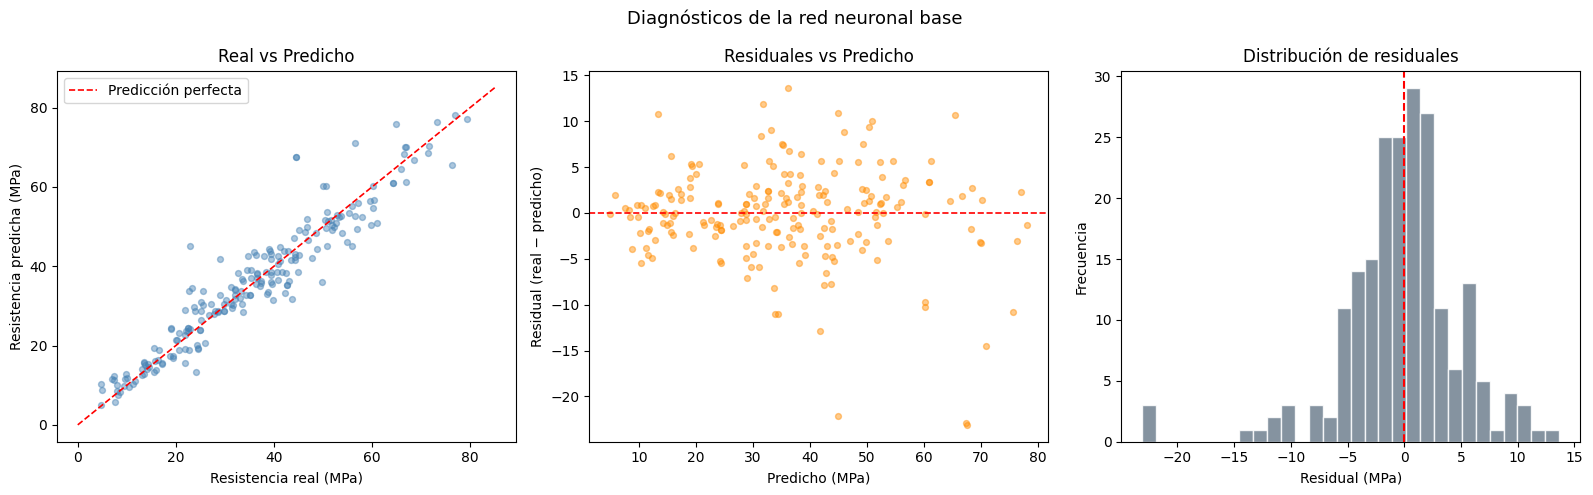

Media de residuales  : -0.199
Std  de residuales   : 5.213


In [13]:
residuals = y_true_mpa.flatten() - y_pred_mpa.flatten()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Gráfica 1: Real vs Predicho
ax = axes[0]
ax.scatter(y_true_mpa, y_pred_mpa, alpha=0.45, s=18, color="steelblue")
lims = [0, 85]
ax.plot(lims, lims, "r--", linewidth=1.2, label="Predicción perfecta")
ax.set_xlabel("Resistencia real (MPa)")
ax.set_ylabel("Resistencia predicha (MPa)")
ax.set_title("Real vs Predicho")
ax.legend()

# Gráfica 2: Residuales vs Predicho
ax = axes[1]
ax.scatter(y_pred_mpa, residuals, alpha=0.45, s=18, color="darkorange")
ax.axhline(0, color="red", linestyle="--", linewidth=1.2)
ax.set_xlabel("Predicho (MPa)")
ax.set_ylabel("Residual (real − predicho)")
ax.set_title("Residuales vs Predicho")

# Gráfica 3: Distribución de residuales
ax = axes[2]
ax.hist(residuals, bins=30, color="slategray", edgecolor="white", alpha=0.85)
ax.axvline(0, color="red", linestyle="--")
ax.set_xlabel("Residual (MPa)")
ax.set_ylabel("Frecuencia")
ax.set_title("Distribución de residuales")

plt.suptitle("Diagnósticos de la red neuronal base", fontsize=13)
plt.tight_layout()
plt.show()

print(f"Media de residuales  : {residuals.mean():.3f}")
print(f"Std  de residuales   : {residuals.std():.3f}")

* *Pregunta 4.2 Pega las tres gráficas. Para cada una, escribe al menos dos observaciones:*
  - Real vs Predicho: ¿hay sesgo sistemático? ¿el modelo predice igual de bien en valores bajos que en valores altos de resistencia?
 
    
    Los datos siguen de forma cercana la predicción perfecta. Esto implica que la red neuronal no está haciendo overfitting o underfitting la resistencia general de todo el dataset.
    En valores entre 10 y 40 MPa se observa una mejor predicción de los datos, concentrados cerca de la línea; mientras que en valores mayores a 50MPa, los datos se dispersan de forma considerable, indicando que la red no llega a modelar el comportamiento del concreto con demasiada resistencia.
    
  - Residuales vs Predicho: ¿hay homocedasticidad o el patrón de los errores cambia con el valor predicho?
 
    No hay una homocedasticidad perfecta. En la nube de puntos, el margen de error es más estrecha a la izquierda y se va ensanchando gradualmente hacia la derecha. Esto confirma que el patrón de los errores cambia: a mayor resistencia predicha, mayor es la varianza del error.
 
    A pesar del ensanchamiento, los errores parecen estar balanceados por arriba y debajo de la linea. Esto se confirma con la media de residuales con valor de -0.199.
  - Distribución de residuales: ¿es aproximadamente simétrica? ¿hay outliers evidentes?
 
    El histograma tiende a una forma acampanada, con una simetría centrada en 0, lo que nos da la idea de que la mayoría de errores del modelo son pequeños y aleatorios. Existen valores atípicos en la cola izquierda de los datos, lo que significa que existen mezclas donde el modelo predijo una resistencia mayor para un concreto débil.
 

* *Pregunta 4.3 El supuesto de normalidad de residuales importaba mucho en regresión lineal para inferencia estadística (intervalos de confianza, p-values). En una red neuronal entrenada por minimización de MSE, ¿ese supuesto sigue siendo necesario? ¿Qué sí y qué no cambia?*

  Ya no es estricta en redes neuronales. Esto se debe a que las redes son herramientas para la predicción, no para inferencia clásica. Por lo tanto, si los residuales no forman una campana de Gauss perfecta, el algoritmo de backpropagation sigue funcionando y el modelo sigue entregando predicciones válidas.

  Esto no implica que la distribución de errores no es importante, debido a que gracias a estos podemos identificar si la red presentan errores sistemáticos graves.

# Parte 5: Experimentos sistemáticos

La regla de esta parte es estricta: cambia solo una cosa por experimento. Si cambias dos variables simultáneamente, no puedes saber qué causó qué. Es el mismo principio que un experimento controlado en laboratorio.

## 5.1 Experimento 1: Learning rate

In [14]:
def experimento_lr(lr_list, n_epochs=300):
    resultados = {}
    for lr in lr_list:
        m = ConcreteNet(8, 64, 1, dropout_rate=0.0).to(device)
        opt = optim.Adam(m.parameters(), lr=lr)
        crit = nn.MSELoss()
        hist_train, hist_val = [], []
        for _ in range(n_epochs):
            m.train()
            bl = []
            for Xb, yb in train_loader:
                opt.zero_grad()
                loss = crit(m(Xb), yb)
                loss.backward()
                opt.step()
                bl.append(loss.item())
            m.eval()
            with torch.no_grad():
                vl = crit(m(X_val_t), y_val_t).item()
            hist_train.append(np.mean(bl))
            hist_val.append(vl)
        resultados[lr] = (hist_train, hist_val)
        print(f"  lr={lr:.0e} | Val Loss final: {hist_val[-1]:.4f}")
    return resultados

print("Experimento: learning rate")
res_lr = experimento_lr([1e-1, 1e-2, 1e-3, 1e-4])

Experimento: learning rate
  lr=1e-01 | Val Loss final: 0.3589
  lr=1e-02 | Val Loss final: 0.0824
  lr=1e-03 | Val Loss final: 0.1109
  lr=1e-04 | Val Loss final: 0.1263


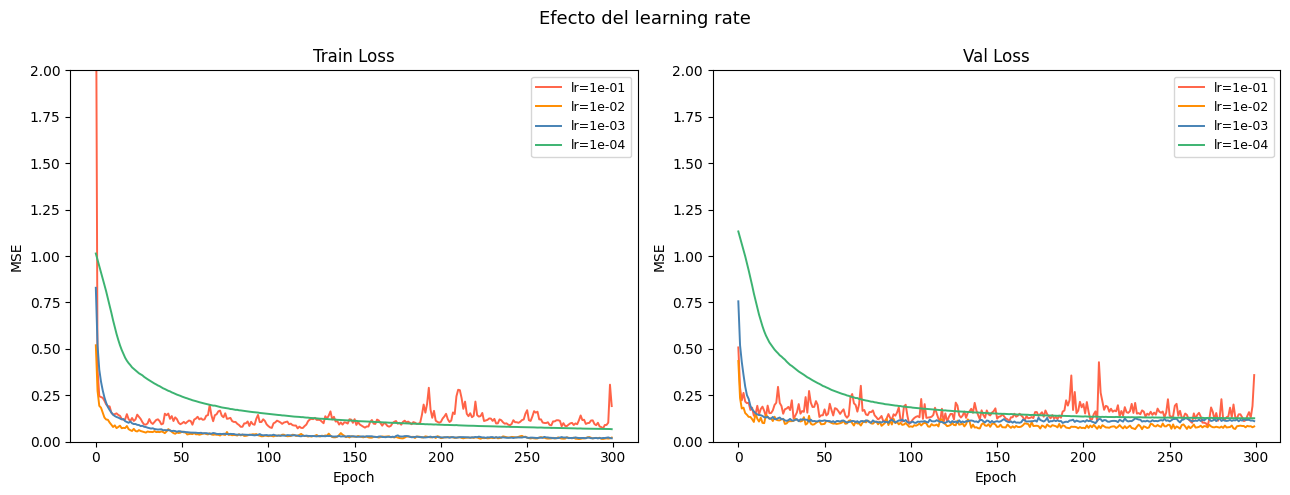

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = ["tomato", "darkorange", "steelblue", "mediumseagreen"]
lrs    = [1e-1, 1e-2, 1e-3, 1e-4]

for ax_idx, key in enumerate(["Train", "Val"]):
    ax = axes[ax_idx]
    for lr, color in zip(lrs, colors):
        hist = res_lr[lr][ax_idx]
        ax.plot(hist, label=f"lr={lr:.0e}", color=color, linewidth=1.4)
    ax.set_title(f"{key} Loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MSE")
    ax.legend(fontsize=9)
    ax.set_ylim(0, 2.0)

plt.suptitle("Efecto del learning rate", fontsize=13)
plt.tight_layout()
plt.show()

* *Pregunta 5.1 Pega la gráfica. Describe el comportamiento para cada learning rate. ¿Cuál diverge, cuál converge demasiado lento, cuál tiene el mejor balance? Conecta lo que ves con lo que viste en los slides 100–102 del lunes.*

  La línea roja (lr= 0.1) oscila de manera brusca durante la mayor parte de los epoch, debido a que el optimizador da saltos sin detenerse en el fondo, terminando con el peor error de validación (0.3589).
  
  La línea verde (lr = 0.0001) presenta una convergencia lenta y pronunciada, al dar pasos tan pequeños , la curva tiene un descenso más suave y constante. Después de 300 iteraciones, la curva sigue bajando (no se ha aplanado del todo), lo que significa que el entrenamiento se detuvo antes de que pudiera encontrar el mínimo real.

  La línea azul (lr = 0.001) presenta una convergencia suave, controlada y sin ruido, encontrando un buen mínimo alrededor de 0.1109. Es por esto que es el valor por defecto de Adam.

  Por último la línea naranja (lr = 0.01) logró el mejor error de validación final (0.0824), debido a que aceleró el descenso sin volverse inestable, aunque tiene presencia de ruido.

  La tasa de aprendizaje controla el tamaño del paso que da la red al actualizar sus pesos. Si el paso es gigante (1e-1), se destruye la precisión y la pérdida oscila. Si el paso es minúsculo (1e-4), el tiempo de cómputo que se requiere es mayor para llegar al objetivo. La meta es poder encontrar ese punto medio como lo fueron 1e-2 y 1e-3 en tu experimento.

## 5.2 Experimento 2: Tamaño del batch

In [16]:
def experimento_batch(batch_sizes, n_epochs=200):
    resultados = {}
    for bs in batch_sizes:
        loader = DataLoader(train_dataset, batch_size=bs, shuffle=True)
        m = ConcreteNet(8, 64, 1).to(device)
        opt = optim.Adam(m.parameters(), lr=1e-3)
        crit = nn.MSELoss()
        hist_train, hist_val = [], []
        for _ in range(n_epochs):
            m.train()
            bl = []
            for Xb, yb in loader:
                opt.zero_grad()
                loss = crit(m(Xb), yb)
                loss.backward()
                opt.step()
                bl.append(loss.item())
            m.eval()
            with torch.no_grad():
                vl = crit(m(X_val_t), y_val_t).item()
            hist_train.append(np.mean(bl))
            hist_val.append(vl)
        rmse, _, _, _ = evaluate(m, X_test_t, y_test_sc, scaler_y)
        resultados[bs] = {"train": hist_train, "val": hist_val, "rmse_test": rmse}
        print(f"  batch={bs:4d} | Val Loss final: {hist_val[-1]:.4f} | RMSE test: {rmse:.2f} MPa")
    return resultados

print("Experimento: batch size")
res_batch = experimento_batch([8, 32, 128, 824])  # 824 ≈ todo el train set

Experimento: batch size
  batch=   8 | Val Loss final: 0.0935 | RMSE test: 5.20 MPa
  batch=  32 | Val Loss final: 0.0768 | RMSE test: 4.89 MPa
  batch= 128 | Val Loss final: 0.1264 | RMSE test: 5.53 MPa
  batch= 824 | Val Loss final: 0.1050 | RMSE test: 6.35 MPa


* *Pregunta 5.2 Anota los RMSE de prueba para cada batch size. ¿Hay diferencias notables? En clase viste el trade-off entre batch pequeño (gradiente ruidoso) y batch grande (gradiente estable). ¿Ese trade-off se manifiesta en tus resultados? ¿Por qué batch=824 es equivalente a batch gradient descent en este caso?*

  Las diferencias son notables, hay diferencia de 1.5 MPa entre el mejor lote y el peor. En la resistencia del concreto, equivocarse por 1.5 Megapascales extra en promedio puede ser la diferencia entre una mezcla aprobada o rechazada en obra. El punto óptimo para la red claramente está alrededor de 32.

  En lotes muy pequeños, el gardiente es altamente estocástico. Puede ser eficaz para poder salir de mínimos locales falsos, pero impide al optimizadoer asentarse en el fondo exacto del mínimo local.

  En lotes intermedios, se presenta el suficiente ruido para explorar el espacio y generalizar, y es suficiuente para que la dirección del gradiente sea precisa.

  En los lotes grandes, el gradiente se vuelve muy estable, pero generaliza peor, debido a que al no presentar ruido tienden a caer en mínimos locales que memorizan el conjunto de entrenamiento.

  El dataset original presenta 1030 observaciones de concreto, al dividirlo en 80-20, el conjunto de entrenamiento presenta exzactamente 824 filas. ASl configurar el tamaño del batch igual al tamaño total de tu conjunto de entrenamiento, el concepto de "mini-batch" desaparece. En lugar de dar decenas de pequeños pasos por epoch, la red calculará el error promedio de todos los datos simultáneamente y dará un solo paso de actualización de pesos por epoch. 

## 5.3 Experimento 3: Arquitectura

Completa la siguiente tabla. Usa n_epochs=300 en todos los casos para mantener comparabilidad, y el mismo SEED.

In [17]:
arquitecturas = {
    "Shallow-64"    : {"hidden_dim": 64,  "n_layers": 1},
    "Base (2x64)"   : {"hidden_dim": 64,  "n_layers": 2},
    "Deep (3x64)"   : {"hidden_dim": 64,  "n_layers": 3},
    "Wide (2x256)"  : {"hidden_dim": 256, "n_layers": 2},
    "Tiny (2x16)"   : {"hidden_dim": 16,  "n_layers": 2},
}

# Para variar el número de capas necesitas modificar ConcreteNet.
# Aquí tienes una versión flexible:

class FlexNet(nn.Module):
    def __init__(self, input_dim, hidden_dim, n_layers, output_dim, dropout_rate=0.0):
        super(FlexNet, self).__init__()
        layers = [nn.Linear(input_dim, hidden_dim), nn.ReLU()]
        for _ in range(n_layers - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
                       nn.Dropout(p=dropout_rate)]
        layers += [nn.Linear(hidden_dim, output_dim)]
        self.net = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.net(x)

resultados_arch = {}
for nombre, cfg in arquitecturas.items():
    torch.manual_seed(SEED)
    m = FlexNet(8, cfg["hidden_dim"], cfg["n_layers"], 1).to(device)
    th, vh, st = train_model(m, train_loader, X_val_t, y_val_t,
                              n_epochs=300, patience=25, verbose_every=999)
    rmse, mae, _, _ = evaluate(m, X_test_t, y_test_sc, scaler_y, nombre)
    n_params = sum(p.numel() for p in m.parameters())
    resultados_arch[nombre] = {"rmse": rmse, "params": n_params}

  Early stopping en epoch 128.
Shallow-64                     | RMSE: 5.96 MPa | MAE: 4.46 MPa
  Early stopping en epoch 119.
Base (2x64)                    | RMSE: 5.22 MPa | MAE: 3.61 MPa
  Early stopping en epoch 115.
Deep (3x64)                    | RMSE: 5.39 MPa | MAE: 3.60 MPa
  Early stopping en epoch 156.
Wide (2x256)                   | RMSE: 4.80 MPa | MAE: 3.22 MPa
  Early stopping en epoch 144.
Tiny (2x16)                    | RMSE: 6.45 MPa | MAE: 4.74 MPa


| Arquitectura | Parámetros | RMSE Test (MPa) |
| :--- | :--- | :--- |
| **Shallow-64** | 641 | 5.96 |
| **Base (2×64)** | 4,801 | 5.22 |
| **Deep (3×64)** | 8,961 | 5.39 |
| **Wide (2×256)** | 68,353 | 4.80 |
| **Tiny (2×16)** | 433 | 6.45 |

* *Pregunta 5.3 Llena la tabla y responde: a) ¿El modelo con más parámetros tiene el mejor RMSE? ¿Qué dice eso sobre la relación entre tamaño del modelo y desempeño en datasets pequeños? b) ¿Cuál arquitectura tiene la mejor relación parámetros/desempeño? c) Elige la arquitectura que usarías en producción para este problema específico y justifica la elección considerando no solo el RMSE sino también el número de parámetros.*

  El modelo Wide (2x256) presenta mayor cantidad de parámetros (68353) y tiene el mejor RSME (4.8 MPa). Con esto podemos conocer que la relación no es lineal ni garantizada. El cambio enre Base y Deep aumentó la capacidad en parámetros, pero empeoró el desempeño (el MSE subió). Agregar demasiada profundidad a modelos con  pocas observaciones como es en este caso del concreto, el modelo empieza a memorizar el ruido y hace que el gradiente se haga más dificl de propagar.

  La Base (2x64) logra una mejor relación entre parámetro y desempeño. Logra un desempeño excelente (5.22 MPa) utilizando solo 4,801 parámetros. Comparado con el modelo Wide que logra reducir el error apenas 0.42 MPa extra, pero a costa de multiplicar la complejidad computacional casi 14 veces. Para un problema tabular simple de 8 variables, esa cantidad de parámetros es un exceso de fuerza bruta.

  Una elección correcta es la Base (2x64) debido a que da un error altamente estable, es computacionalmente ligero  y es mucho más robusto y confiable a largo plazo ante datos nuevos. La cantidad de parámetros en Wide es increiblemente mayor que la cantidad de observaciones del dataset, lo que lo convierte en un riesgo gigante de sobreajuste masivo si los datos reales de la planta de concreto llegan a variar ligeramente respecto a la muestra de entrenamiento
  

## 5.4 Experimento 4: Dropout como regularización

In [18]:
tasas_dropout = [0.0, 0.1, 0.3, 0.5]
resultados_dropout = {}

for rate in tasas_dropout:
    torch.manual_seed(SEED)
    m = ConcreteNet(8, 64, 1, dropout_rate=rate).to(device)
    th, vh, st = train_model(m, train_loader, X_val_t, y_val_t,
                              n_epochs=300, patience=25, verbose_every=999)
    rmse, _, _, _ = evaluate(m, X_test_t, y_test_sc, scaler_y,
                              f"Dropout={rate}")
    resultados_dropout[rate] = {"rmse": rmse, "train": th, "val": vh}

  Early stopping en epoch 119.
Dropout=0.0                    | RMSE: 5.22 MPa | MAE: 3.61 MPa
  Early stopping en epoch 181.
Dropout=0.1                    | RMSE: 5.20 MPa | MAE: 3.61 MPa
  Early stopping en epoch 125.
Dropout=0.3                    | RMSE: 6.07 MPa | MAE: 4.59 MPa
  Early stopping en epoch 104.
Dropout=0.5                    | RMSE: 6.62 MPa | MAE: 5.27 MPa


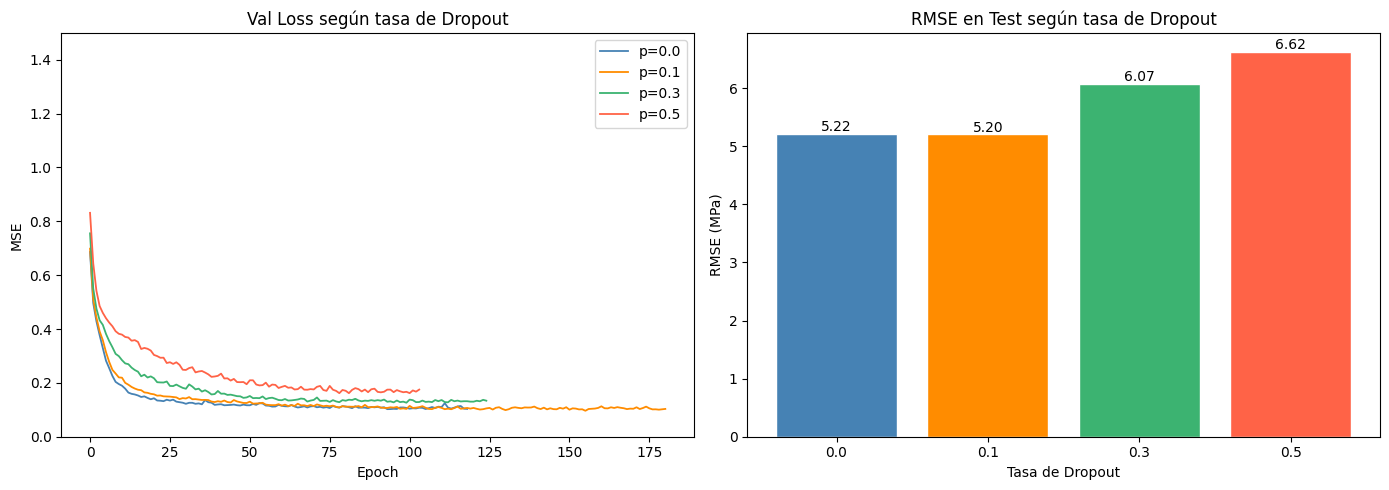

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colores = ["steelblue", "darkorange", "mediumseagreen", "tomato"]

# Curvas val loss
ax = axes[0]
for rate, color in zip(tasas_dropout, colores):
    vh = resultados_dropout[rate]["val"]
    ax.plot(vh, label=f"p={rate}", color=color, linewidth=1.3)
ax.set_title("Val Loss según tasa de Dropout")
ax.set_xlabel("Epoch"); ax.set_ylabel("MSE")
ax.legend(); ax.set_ylim(0, 1.5)

# RMSE final
ax = axes[1]
rmses = [resultados_dropout[r]["rmse"] for r in tasas_dropout]
bars  = ax.bar([str(r) for r in tasas_dropout], rmses,
               color=colores, edgecolor="white")
ax.set_title("RMSE en Test según tasa de Dropout")
ax.set_xlabel("Tasa de Dropout"); ax.set_ylabel("RMSE (MPa)")
for bar, val in zip(bars, rmses):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f"{val:.2f}", ha="center", fontsize=10)

plt.tight_layout()
plt.show()

* *Pregunta 5.4 Pega las gráficas. ¿A qué tasa de Dropout se obtiene el mejor RMSE? ¿Tiene sentido intuitivo que Dropout muy alto (0.5) pueda aumentar el error? Explica en términos del concepto de underfitting.*

  El mejor desempeño lo tiene la tasa de Dropout de 0.1, logrando un RMSE de 5.20 MPa. Muestra un desempeño similar al de Dropout de 0.0 con 5.22 de MPa. Esto nos indica que apagar aleatoriamente el 10% de las neuronas ayudó a mejorar la generalización de la red.

  La arquitectura base es pequeña, por lo que el Dropout de 0.5 significa que se desconectan aleatoriamente la mitad de las neuronas de la red en cada iteración. Con esto no le damos la capacidad ni profundidad a la red necesarias para entender las interacciones complejas en los componentes del concreto (como la relación agua-cemento). El resultado puede llegar a generar underfitting en el modelo. 

* *Pregunta 5.5 Dropout se desactiva durante la inferencia (model.eval()). Si olvidaras llamar model.eval() antes de evaluar en test, ¿qué efecto concreto tendría en tus predicciones? ¿Serían deterministas o no?*

  Si no se llama el model.eval(), la red estuviera en un proceso de prueba apagando un porcentaje de las neuronas aleatoriamente, lo que generaría métricas de error artificiales y altas. Con esto, el modelo dejaría de ser determinista, debido a que la capa de Dropout seguiría silenciando neuronas y el flujo de informació cambiaría en cada pasada. Los resultados de validación serían estocásticos, erráticos y no reproducibles.

  

# Parte 6: Inspección de gradientes
Esta parte va un nivel más adentro. Vamos a observar los gradientes directamente para entender el problema del vanishing gradient.

## 6.1 Gradientes por capa

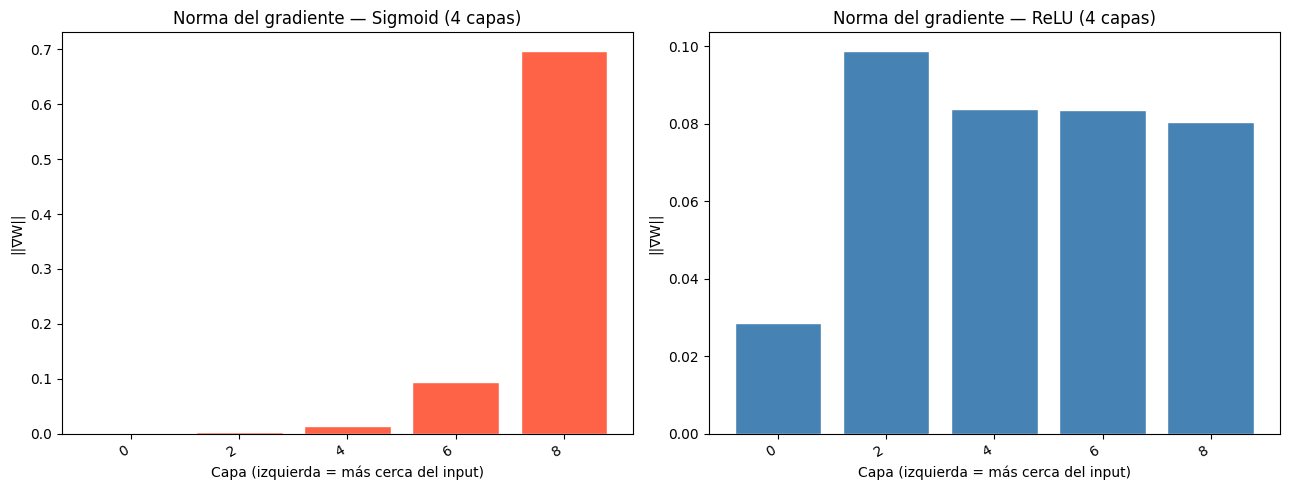

In [20]:
# Entrenamos brevemente un modelo con sigmoid para comparar contra ReLU

class NetSigmoid(nn.Module):
    def __init__(self, input_dim=8, hidden_dim=64, output_dim=1, n_layers=4):
        super(NetSigmoid, self).__init__()
        layers = [nn.Linear(input_dim, hidden_dim), nn.Sigmoid()]
        for _ in range(n_layers - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.Sigmoid()]
        layers += [nn.Linear(hidden_dim, output_dim)]
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x)

class NetReLU(nn.Module):
    def __init__(self, input_dim=8, hidden_dim=64, output_dim=1, n_layers=4):
        super(NetReLU, self).__init__()
        layers = [nn.Linear(input_dim, hidden_dim), nn.ReLU()]
        for _ in range(n_layers - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.ReLU()]
        layers += [nn.Linear(hidden_dim, output_dim)]
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x)

def get_grad_norms(model_class, X_t, y_t, n_steps=50):
    """
    Realiza n_steps de entrenamiento y registra la norma del gradiente
    de cada capa lineal al final.
    """
    torch.manual_seed(SEED)
    m = model_class().to(device)
    opt = optim.SGD(m.parameters(), lr=1e-3)
    crit = nn.MSELoss()
    
    for _ in range(n_steps):
        m.train()
        opt.zero_grad()
        loss = crit(m(X_t), y_t)
        loss.backward()
        opt.step()
    
    # Recolectar normas del gradiente por capa lineal
    grad_norms = []
    layer_names = []
    for name, param in m.named_parameters():
        if "weight" in name and param.grad is not None:
            grad_norms.append(param.grad.norm().item())
            layer_names.append(name.replace(".weight", ""))
    
    return layer_names, grad_norms

names_sig, norms_sig = get_grad_norms(NetSigmoid, X_train_t, y_train_t)
names_rel, norms_rel = get_grad_norms(NetReLU,    X_train_t, y_train_t)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, names, norms, title, color in [
    (axes[0], names_sig, norms_sig, "Sigmoid (4 capas)", "tomato"),
    (axes[1], names_rel, norms_rel, "ReLU (4 capas)",    "steelblue"),
]:
    ax.bar(range(len(norms)), norms, color=color, edgecolor="white")
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels([n.split(".")[-1] for n in names], rotation=30, ha="right")
    ax.set_title(f"Norma del gradiente — {title}")
    ax.set_ylabel("||∇W||")
    ax.set_xlabel("Capa (izquierda = más cerca del input)")

plt.tight_layout()
plt.show()

* *Pregunta 6.1 Pega las dos gráficas. ¿Ves diferencia entre la red con Sigmoid y la red con ReLU en cuanto a cómo se distribuyen los gradientes entre capas? ¿La primera capa (más a la izquierda) recibe gradientes de magnitud comparable a la última? Conecta lo que ves con la explicación de vanishing gradients de los slides 40–41 del lunes.*

  La red con Sigmoid presenta una caída exponencial conforme nos movemos de la capa de salida hacia la capa de entrada. La capa con índice 8 presenta un gradiente de 0.7, pero al llegar a al primera capa el gradiente colapsa a un valor que se aproxima a 0. En la red ReLU, los gradientes de distribuyen de manera más uniforme, con variaciones comparables en la misma escala de todas las capas.

  La función Sigmoid aplasta cualquier número de entrada entre 0 y 1, por lo que su derivada máxima es en el punto central con apenas 0.25. En el backpropagation, la regla de la cadena implica multiplicar las derivadas de cada capa hacia atrás, por lo que al multiplicar muchas veces 0.25 por si mismo, esta colapsará a 0. Esto hace que las primeras capas queden sin gradiente y no puedan actualizar sus pesos ni aprendier. Esto se ve en la definición de Vanishing Gradient Problem. 
  
* *Pregunta 6.2 En el código usamos optim.SGD en lugar de Adam deliberadamente para este experimento. ¿Por qué Adam podría enmascarar el efecto del vanishing gradient y hacer menos visible la diferencia?*

  optim.SGD toma el gradiente puro y lo multiplica por el learning rate fijo, lo que nos permite observar la magnitud real del gradiente. Adam calcula un tamaño de paso individual para cada peso, dividiendo el gradiente entre la raíz cuadrada de la varianza histórica del gradiente. Con esto, se amplifican los gradientes débiles y amortigua los fuertes. 

# Parte 7: Depuración (encuentra el error)
El siguiente código tiene tres errores deliberados. Cada uno produce o un resultado silenciosamente incorrecto o un crash. Encuéntralos, explica por qué cada uno es un error, y corrígelos.

No uses el stack trace como única guía: algunos errores no hacen crash, solo producen resultados incorrectos.

In [21]:
# ── CÓDIGO CON ERRORES ──────────────────────────────────────────────

scaler_debug = StandardScaler()
X_train_bug = scaler_debug.fit_transform(X_train)
X_test_bug  = scaler_debug.fit_transform(X_test)       # ERROR 1

torch.manual_seed(SEED)
model_debug = ConcreteNet(8, 64, 1).to(device)
opt_debug   = optim.Adam(model_debug.parameters(), lr=1e-3)
crit_debug  = nn.MSELoss()

X_tr = to_tensor(X_train_bug)
y_tr = to_tensor(y_train_sc)

for epoch in range(50):
    model_debug.train()
    for Xb, yb in DataLoader(TensorDataset(X_tr, y_tr), batch_size=32):
        loss = crit_debug(model_debug(Xb), yb)
        loss.backward()                                 # ERROR 2
        opt_debug.step()
        opt_debug.zero_grad()

model_debug.eval()
y_debug_pred = model_debug(X_test_t).detach().numpy()  # ERROR 3

print(f"Predicción ejemplo: {y_debug_pred[0]}")

Predicción ejemplo: [-1.6552875]


* *Pregunta 7.1 Identifica los tres errores. Para cada uno: a) Señala la línea exacta y el comentario que lo marca. b) Explica por qué es un error (qué produce que es incorrecto o problemático). c) Escribe la corrección.*

  El primer error ocurre al hacer el scaler en los datos, debido a que se utliza el .fit_transfomr() en el set de test. Esto es un error grave como se ha mencionado anteriormente debido a que se está haciendo un Data Leakage, debido a que el .fit_transform() calcula la media de los datos del test y lo transforma, en lugar de usar los estadísticos de los datos de entremanieto. La forma correcta es usar solamente e. .fit_transform() en el set de train, y usar .transform() con el test set.

  El segundo error ocurre al usar loss.backward() antes de hacer la limpieza del gradiente. Aunque existe un opt_debug.zero_grad() al final del bloque, lo seguro es llamarlo antes del cálculo de la pérdida o del forward pass. Puede ocurrir el caso donde la primera itereación acumula gradientes de la ejecución anterior. Lo correcto sería mover la limpieza de gradientes al inicio del ciclo de batches.

  El tercer error ocurre en y_debug_pred = model_debug(X_test_t).detach().numpy(), debido a que evalua sin usar el bloque with torch.no_grad():. Poner .detach() al final solo esconde el problema: PyTorch desperdició recursos y memoria RAM construyendo un grafo computacional invisible (el mapa de derivadas) durante el forward pass, a pesar de que en la fase de prueba no se necesita hacer backpropagation. Además, si se estuviera usando GPU, causaría un crash por no pasar el tensor a la CPU antes de convertirlo a NumPy. La correción pertinente es usar
  
      with torch.no_grad():
          y_debug_pred = model_debug(X_test_t).cpu().numpy()
  

# Parte 8: Comparación final y análisis crítico


## 8.1 Ridge como línea base


In [30]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

# Ridge con búsqueda de alpha en el mismo train set
ridge_cv = GridSearchCV(
    Ridge(), {"alpha": [0.01, 0.1, 1.0, 10.0, 100.0]},
    cv=5, scoring="neg_mean_squared_error"
)
ridge_cv.fit(X_train_sc, y_train_sc.ravel())
print(f"Mejor alpha Ridge: {ridge_cv.best_params_['alpha']}")

y_ridge_sc  = ridge_cv.predict(X_test_sc).reshape(-1, 1)
y_ridge_mpa = scaler_y.inverse_transform(y_ridge_sc)
rmse_ridge  = np.sqrt(mean_squared_error(y_true_mpa, y_ridge_mpa))
mae_ridge   = np.mean(np.abs(y_true_mpa - y_ridge_mpa))

print(f"\nComparación final:")
print(f"{'Modelo':<35} {'RMSE (MPa)':>12} {'MAE (MPa)':>12} {'Parámetros':>12}")
print("-" * 75)
print(f"{'Ridge (mejor alpha)':<35} {rmse_ridge:>12.2f} {mae_ridge:>12.2f} {'9':>12}")
print(f"{'Red Neuronal (base 2x64)':<35} {rmse_nn:>12.2f} {mae_nn:>12.2f} {'4,801':>12}")

Mejor alpha Ridge: 0.01

Comparación final:
Modelo                                RMSE (MPa)    MAE (MPa)   Parámetros
---------------------------------------------------------------------------
Ridge (mejor alpha)                        11.04         8.84            9
Red Neuronal (base 2x64)                    5.22         3.61        4,801


* *Pregunta 8.1 Llena la tabla. ¿Cuál modelo tiene menor RMSE? ¿La diferencia es estadísticamente y prácticamente significativa?*

  El modelo con la Red Neuronal (Base 2x64) presenta menor RSME de la misma forma que presenta el menor MAE. A diferencia de los valores de Ridge que son más del doble que los de la red neuronal.

  La diferencia entre estos valores son significativos en el contexto del problema. Reducir el error por la mitad se vuelve relevante. Los errores promedios de 11.04 MPa en la resistencia del concreto se vuelven en un riesgo estructural, o desperdicios monetarios. Tener errores que ronden por los 5 MPa o menos son más manejables en las tolerancias de seguridad de diseños estructurales.

  El problema de la regresión Ridge es que asume que la relación entre las variables (cemento, agua, edad, etc.) y la resistencia es estrictamente lineal. La física de los materiales no funciona así; la resistencia depende de interacciones altamente no lineales (como la proporción exacta de agua-cemento y la curva logarítmica de fraguado a través del tiempo). La red neuronal, al tener capas ocultas y funciones de activación ReLU, es capaz de aproximar estas complejas funciones no lineales, reduciendo el error a menos de la mitad. El modelo Ridge sufre de un grave caso de underfitting por falta de capacidad representativa.

## 8.2 Gráfica comparativa de residuales


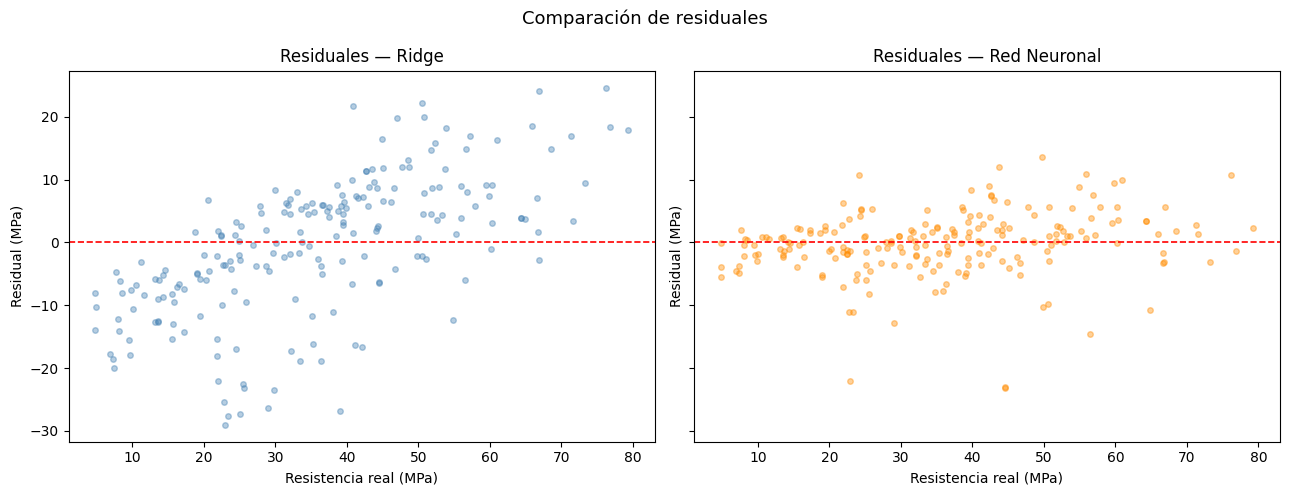

In [29]:
resid_ridge = y_true_mpa.flatten() - y_ridge_mpa.flatten()
resid_nn    = y_true_mpa.flatten() - y_pred_mpa.flatten()

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for ax, resid, title, color in [
    (axes[0], resid_ridge, "Residuales — Ridge",          "steelblue"),
    (axes[1], resid_nn,    "Residuales — Red Neuronal",   "darkorange"),
]:
    ax.scatter(y_true_mpa, resid, alpha=0.4, s=16, color=color)
    ax.axhline(0, color="red", linestyle="--", linewidth=1.2)
    ax.set_xlabel("Resistencia real (MPa)")
    ax.set_ylabel("Residual (MPa)")
    ax.set_title(title)

plt.suptitle("Comparación de residuales", fontsize=13)
plt.tight_layout()
plt.show()

* *Pregunta 8.2 Pega la gráfica. ¿Hay diferencias en el patrón de residuales entre los dos modelos? ¿Alguno tiene sesgos sistemáticos que el otro no tiene?*

  En los residuos de Ridge se puede encontrar un patrón lineal creciente. Esto se puede interpretar que el modelo lineal sobreestima consistentemente la resistencia en mezclas débiles (predice de más) y subestima severamente las mezclas muy fuertes (predice de menos). Esto ocurre porque una línea recta no puede doblarse para seguir la curva logarítmica natural del endurecimiento del concreto con la edad.

  Por otra parte, la nube residual que genera la red neuronal se distribuye más horizontal y aleatoria alrededor de la línea del cero. Carece del sesgo sistemático severo de Ridge. El balance entre errores positivos y negativos se mantiene mucho más simétrico y centrado.

## 8.3 La pregunta que importa


* *Pregunta 8.3 Tu red neuronal base tiene entre 4,000 y 20,000 parámetros dependiendo de la arquitectura que elegiste. Ridge tiene 9. Con esa diferencia en mente, y con los resultados en la mano, responde las siguientes preguntas con argumentos, no solo con el número de RMSE:*

    - ¿La diferencia en RMSE es prácticamente significativa para el problema de ingeniería civil? En concreto estructural, un error de 2 MPa puede ser relevante o irrelevante según el contexto de uso. ¿Qué contextos harían esa diferencia crítica y cuáles no?
          Reducir el error de ~11 MPa a ~5 MPa es abismalmente significativo, pero el impacto de un error marginal (como 2 MPa) depende enteramente del contexto:
 
      En elementos no estructurales sometidos a baja carga como banquetas o pisos simples o en estructuras masivas donde los factores de seguridad están sobrados por diseño puede ser irrelevante la diferencia de error. En concreto de alto rendimiento utilizado en rascacielos, vigas de puentes postensados, o túneles profundos, subestimar la resistencia por 2 MPa provoca un desperdicio millonario de cemento (sobrediseño); sobreestimarla por 2 MPa compromete la integridad estructural y arriesga colapsos bajo cargas sísmicas o de viento.

    - Si tuvieras que presentar tus resultados a un comité de ingenieros civiles que no saben nada de machine learning, ¿cuál modelo presentarías y por qué? Piensa en interpretabilidad, confianza del cliente y riesgo.
 
      Para convencer a un comité, la estrategia más sólida es presentar ambos modelos de forma secuencial, utilizando uno para validar la intuición física y el otro para resolver el problema matemático:
 
      Primero presentaría Ridge: El uso de sus coeficientes para ganar su confianza. Se demuestra que el modelo entendió la física básica: el coeficiente del agua es muy negativo (a más agua, menos resistencia), el del cemento es positivo.
 
      Luego presentaria la Red Neuronal: Mostraría que Ridge falla (11 MPa de error) porque el curado del concreto no es una línea recta. Presento la red neuronal justificando que, aunque es menos interpretable, es la única herramienta matemática capaz de modelar las interacciones complejas (como el ratio exacto agua/cemento interactuando con los aditivos superplastificantes) reduciendo el error a niveles tolerables para diseño (5 MPa).
 
      
    - ¿Qué agregarías al dataset o qué cambiarías del planteamiento del problema para que una red neuronal tuviera una ventaja más clara sobre regresión lineal? Argumenta en términos de qué hace a las redes neuronales mejores que los modelos lineales.
 
      Agregaría variables no lineales y de interacción:
 
      Edad del concreto en formatos no lineales: log(edad), √(edad), (edad)². La resistencia no aumenta linealmente con el tiempo, sino que sigue una curva logarítmica.
 
      Relaciones agua/cemento y agregado/cemento: En lugar de tener agua, cemento y agregados por separado, crear features que capturen sus proporciones, porque la interacción entre ellos es lo que realmente importa.
 
      Temperatura y humedad de curado: Variables ambientales que tienen efectos no lineales en la hidratación del cemento.
 
      Cambiar el objetivo de predicción:
 
      En lugar de predecir resistencia a 28 días, predecir la curva completa de evolución de resistencia en el tiempo (día 1, 3, 7, 14, 28, 90). Esto es una salida multivariable que una red puede manejar mejor.
 
      Predecir cuantiles de resistencia en lugar del valor esperado, para dar intervalos de confianza.

    - ¿Hay consideraciones éticas en usar un modelo de caja negra para tomar decisiones de diseño estructural? Identifica al menos dos y explica quién asume el riesgo si el modelo se equivoca.
 
     Los dilemas éticos que pueden surgir son:

  Falta de Auditabilidad: Si una estructura falla prematuramente, las autoridades necesitan saber por qué se tomó una decisión de diseño. Con una red neuronal, es matemáticamente casi imposible aislar qué combinación exacta de los 4,801 pesos provocó una mala predicción.

  Sesgo de Automatización: Existe el riesgo ético de que los ingenieros, confíen ciegamente en el algoritmo y dejen de realizar pruebas físicas destructivas, delegando una decisión de seguridad humana a una máquina.

  Legal y éticamente, el algoritmo, la computadora o el científico de datos no asumen la responsabilidad. El riesgo recae sobre el Ingeniero Civil / Director Responsable de Obra (DRO) que firma, sella y aprueba la memoria de cálculo. El algoritmo es solo una herramienta de soporte; el juicio final y la responsabilidad por la vida humana es estrictamente del profesional a cargo.
 
      

# Parte 9: Reflexión sin código
Estas preguntas no requieren ejecutar nada. Requieren pensar.

* *Pregunta 9.1 En el training loop escribiste loss.backward(). Explica qué está calculando PyTorch en esa línea en términos de la regla de la cadena. No necesitas matemática formal: usa la analogía de la cadena de responsabilidad que viste en clase y aplícala concretamente a la primera capa lineal de tu red.*

  Si suponemos que la red neuronal es una empresa de construcción y el error (Loss) es una queja del cliente porque el concreto falló a los 30 MPa en lugar de los 50 prometidos. Al ejecutar loss.backward(), PyTorch inicia una auditoría hacia atrás (la regla de la cadena):
  
    - El jefe (Capa de salida): Recibe la queja y comenta que el número final lo consiguió basándome en los reportes que le entregó la gerencia (capas ocultas).
    - La gerencia (Capas ocultas): Comenta que solo procesan la información que nos manda el departamento de recepción de materiales (primera capa lineal).
    - Recepción de materiales (Primera capa lineal): Esta capa analiza sus conexiones con los datos de entrada, y nos damos cuenta que le dió importancia (un peso muy alto) a la cantidad de agua, y muy poca importancia (un peso muy bajo) a la edad del cemento.

    loss.backward() calcula exactamente qué fracción de culpa tiene cada uno de los parámetros (pesos y sesgos) de esa primera capa sobre el error final. Así, cuando llames al optimizador, este sabrá exactamente qué pesos subir y cuáles bajar para no repetir el error.
  
* *Pregunta 9.2 El Teorema de Aproximación Universal (Cybenko, 1989) dice que una red con una sola capa oculta puede aproximar cualquier función continua. Tienes 1,030 muestras. Hay al menos tres razones distintas por las que ese teorema no garantiza RMSE cercano a cero en este dataset. Menciona tres y explica cada una.*

  El teorema de Cybenko establece que existe alguna configuración de pesos capaz de dibujar cualquier curva. Pero, con solo 1030 muestras de concreto, nos encontramos con:

  1. Falta de densidad de datos: El teorema asume la existencia de suficientes puntos para trazar la función entera. Con solo 1030 mezclas, el espacio está casi vacío. La red tiene que interpolar qué pasa en los huecos entre tus datos, y ahí es donde comete errores.
  2. El problema de la optimización: El teorema dice que los pesos perfectos existen, pero no te dice cómo encontrarlos. Algoritmos como Adam o SGD navegan a ciegas por el espacio de pérdida y pueden quedarse atorados en un "valle" (mínimo local) mucho antes de encontrar la combinación de pesos que garantiza el teorema.
  3. Generalización vs. Memorización: El teorema garantiza que puedes aproximar la función para que el RMSE sea cero en los datos de entrenamiento. Pero si se fuerza a la red a hacer eso, se memorizará el ruido. El RMSE en datos nuevos nunca será cero porque el mundo real tiene varianza e incertidumbre que no estaban en las 1030 muestras originales.

  
* *Pregunta 9.3 En alguno de tus experimentos, ¿el val loss fue consistentemente menor que el train loss durante varias epochs? Si sí ocurrió, explica por qué es posible eso. Si no ocurrió, describe en qué condiciones podría ocurrir y qué significaría.*

 En las gráficas del Experimento 4 (Dropout), se nota que al principio del entrenamiento la línea de validación suele estar por debajo de la de entrenamiento. Esto ocurre principalmente por dos razones:
 1. El efecto del Dropout: Durante el entrenamiento, se tiene activado el Dropout, lo que significa que estás apagando en tu red  neuronas al azar. El train_loss se calcula mientras la red pelea tiene varias neuronas apagadas. Al evaluar el val_loss, se activa el model.eval(), lo que enciende todas las neuronas. La red rinde a su máxima capacidad y, lógicamente, obtiene un error menor.
 2. El desfase temporal de la medición: El train_loss suele ser el promedio del error de todos los lotes a lo largo de un epoch. El val_loss se calcula al final del epoch, cuando la red ya aprendió de todos esos lotes. Se comparando el desempeño promedio del pasado contra el desempeño de la red en su versión más actualizada.
  
* *Pregunta 9.4 Describe qué tendría que ser diferente en este problema (dataset, tarea, objetivo de negocio) para que hubieras tomado la decisión de usar una red neuronal sin hesitar. Sé específico: no digas "más datos", sino cuántos datos y qué tipo de relación entre variables justificaría la complejidad adicional.*

    Para descartar un modelo lineal y justificar el uso de una Red Neuronal, el problema del concreto tendría que escalar masivamente en complejidad, abandonando el formato de una simple tabla estática. Esto es lo que tendría que cambiar: 
    - Pasar de 1,030 muestras a un volumen masivo, a más de 500000 registros históricos provenientes de bases de datos de docenas de plantas concreteras a lo largo de varios años.
    - La justificación real para una red neuronal surgiría al introducir datos no estructurados o series temporales. Por ejemplo, alimentar al modelo con datos de sensores IoT (registros minuto a minuto de la temperatura y humedad interna del cilindro durante los 28 días de curado) o imágenes microscópicas de la porosidad de los agregados.
    - Modelar la cinética de hidratación del cemento es un proceso químico altamente no lineal. Si el objetivo del negocio exigiera predecir no solo la resistencia final a los 28 días, sino pronosticar la curva de endurecimiento en tiempo real bajo condiciones climáticas dinámicas, la regresión lineal colapsaría. Las redes neuronales son aproximadores universales de funciones; su complejidad se justifica plenamente cuando necesitan extraer características de series de tiempo complejas donde las interacciones matemáticas entre variables son imposibles de definir a mano.

* *Pregunta 9.5 A lo largo de esta actividad construiste una red neuronal desde cero. Identifica el momento en el que entendiste algo que antes era confuso — puede ser un concepto del entrenamiento, un resultado de un experimento, o la razón de existir de una línea de código. Descríbelo con precisión.*

    A lo largo de la actividad, el concepto que finalmente comprendí fue la mecánica interna del batch size y su relación con optimizer.step(). Al principio, me resultaba contraintuitivo no pasarle a la red todos los datos de entrenamiento (las ~824 mezclas de concreto) de una sola vez para que calculara el error exacto. Sin embargo, al programar el training loop y anidar el ciclo de los batches dentro del ciclo de los epochs, entendí la diferencia fundamental: los pesos de la red no se actualizan una vez por epoch, sino múltiples veces, dando pequeños pasos por cada lote de 32 cilindros.

  Especialmente en el Experimento 5.2, pude comprobar empíricamente por qué un lote masivo (batch=824) produce un peor desempeño (RMSE de 6.35 MPa) que un lote pequeño (batch=32, RMSE de 4.89 MPa). Entendí que el descenso de gradiente necesita un poco de 'ruido' que le proporcionan los mini-lotes para evitar quedarse atorado en mínimos locales agudos y lograr generalizar mejor el comportamiento real del concreto, en lugar de solo memorizar el conjunto de entrenamiento.

  